In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
raw_df = pd.read_parquet('../data/processed/daily_by_neighborhood.parquet')
raw_df['date'] = pd.to_datetime(raw_df['date'])

value_cols = [col for col in raw_df.columns if col != 'date']
df = raw_df.melt(id_vars='date', value_vars=value_cols, var_name='neighborhood', value_name='count')

# clean up neighborhood names
df['neighborhood'] = df['neighborhood'].astype(str).str.strip()
df = df[df['neighborhood'] != '']
df['count'] = pd.to_numeric(df['count'], errors='coerce').fillna(0.0)

df['year'] = df['date'].dt.year

# sort by neighborhood and date
df = df.sort_values(['neighborhood', 'date']).reset_index(drop=True)

print('Data shape:', df.shape)
print('Neighborhoods:', df['neighborhood'].nunique())
print('Date range:', df['date'].min(), 'to', df['date'].max())
print('Years covered:', sorted(df['year'].unique()))
print('\nSample neighborhoods:')
print(df.groupby('neighborhood')['count'].agg(['min', 'max', 'mean', 'count']).head())

Data shape: (52608, 4)
Neighborhoods: 24
Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00
Years covered: [2019, 2020, 2021, 2022, 2023, 2024]

Sample neighborhoods:
                    min  max       mean  count
neighborhood                                  
Allston               0   19   2.251369   2192
Allston / Brighton    4  366  52.882755   2192
Back Bay              1  145  36.070712   2192
Beacon Hill           0  110  22.000456   2192
Boston                3  126  26.333485   2192


Valid neighborhoods: 24
Train rows (years < 2024): 43824
Test rows (year == 2024): 8784

Test rows per neighborhood:
count     24.0
mean     366.0
std        0.0
min      366.0
25%      366.0
50%      366.0
75%      366.0
max      366.0
dtype: float64


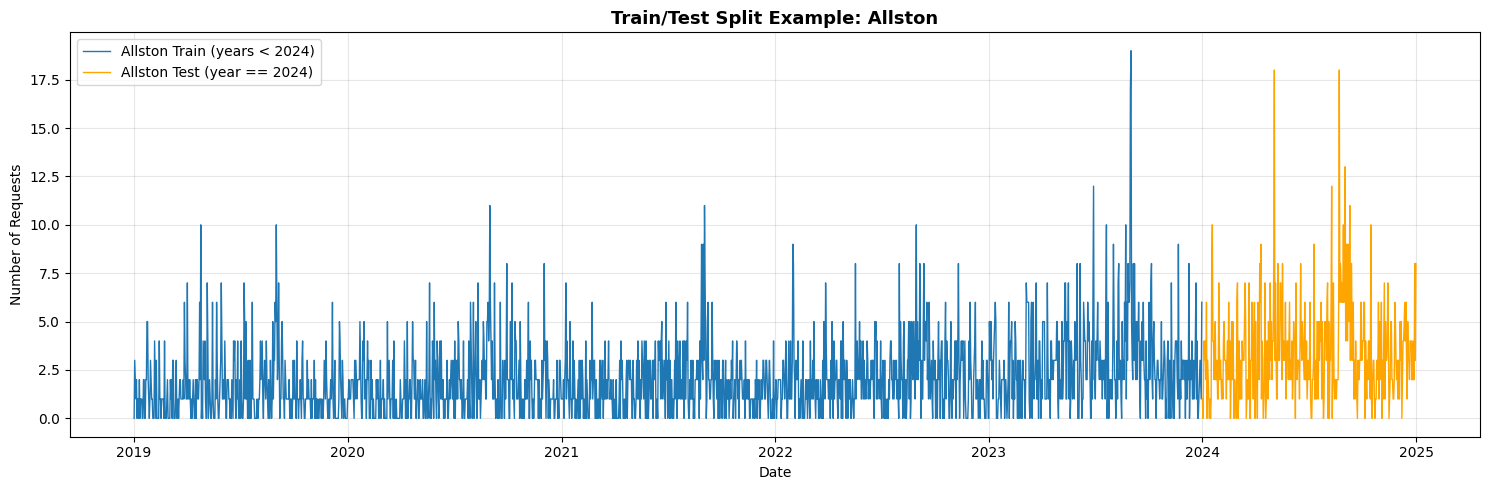

In [ ]:
train = df[df['year'] < 2024].copy()
test = df[df['year'] == 2024].copy()

train_neighborhoods = set(train['neighborhood'].unique())
test_neighborhoods = set(test['neighborhood'].unique())
valid_neighborhoods = sorted(train_neighborhoods & test_neighborhoods)

train_dict = {
    neighborhood: train[train['neighborhood'] == neighborhood].sort_values('date').reset_index(drop=True)
    for neighborhood in valid_neighborhoods
}
test_dict = {
    neighborhood: test[test['neighborhood'] == neighborhood].sort_values('date').reset_index(drop=True)
    for neighborhood in valid_neighborhoods
}

df_model = df[df['neighborhood'].isin(valid_neighborhoods)].copy()

print('Valid neighborhoods:', len(valid_neighborhoods))
print('Train rows (years < 2024):', len(train))
print('Test rows (year == 2024):', len(test))

check = test.groupby('neighborhood').size().describe()
print('\nTest rows per neighborhood:')
print(check)

sample_n = valid_neighborhoods[0]
train_sample = train_dict[sample_n]
test_sample = test_dict[sample_n]

plt.figure(figsize=(15, 5))
plt.plot(
    train_sample['date'],
    train_sample['count'],
    label=f'{sample_n} Train (years < 2024)',
    linewidth=1,
)
plt.plot(
    test_sample['date'],
    test_sample['count'],
    label=f'{sample_n} Test (year == 2024)',
    linewidth=1,
    color='orange',
)
plt.title(f'Train/Test Split Example: {sample_n}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

# AR(1) per neighborhood
per_neighborhood_metrics = []
all_true_pooled = []
all_pred_pooled = []

for neighborhood in valid_neighborhoods:
    y_train = train_dict[neighborhood]['count'].astype(float).values
    y_true = test_dict[neighborhood]['count'].astype(float).values
    
    history = y_train.tolist()
    ar1_pred = []
    
    for actual in y_true:
        hist = np.array(history, dtype=float)
        x_ar = hist[:-1]
        y_ar = hist[1:]
        
        phi, c = np.polyfit(x_ar, y_ar, 1)
        y_hat = c + phi * hist[-1]
        y_hat = max(0.0, y_hat)
        
        ar1_pred.append(y_hat)
        history.append(float(actual))
    
    ar1_pred = np.array(ar1_pred, dtype=float)
    
    mae = mean_absolute_error(y_true, ar1_pred)
    rmse = np.sqrt(mean_squared_error(y_true, ar1_pred))
    mape_val = mape(y_true, ar1_pred)
    r2 = r2_score(y_true, ar1_pred)
    nMAE_pct = (mae / np.mean(y_true) * 100) if np.mean(y_true) > 0 else 0
    
    per_neighborhood_metrics.append({
        'neighborhood': neighborhood,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape_val,
        'R2': r2,
        'nMAE%': nMAE_pct,
    })
    
    all_true_pooled.extend(y_true)
    all_pred_pooled.extend(ar1_pred)

per_nb_df = pd.DataFrame(per_neighborhood_metrics)
macro_metrics = {
    'MAE': per_nb_df['MAE'].mean(),
    'MAE_std': per_nb_df['MAE'].std(),
    'RMSE': per_nb_df['RMSE'].mean(),
    'RMSE_std': per_nb_df['RMSE'].std(),
    'MAPE': per_nb_df['MAPE'].mean(),
    'MAPE_std': per_nb_df['MAPE'].std(),
    'R2': per_nb_df['R2'].mean(),
    'R2_std': per_nb_df['R2'].std(),
    'nMAE%': per_nb_df['nMAE%'].mean(),
    'nMAE%_std': per_nb_df['nMAE%'].std(),
}

pooled_metrics = {
    'MAE': mean_absolute_error(all_true_pooled, all_pred_pooled),
    'RMSE': np.sqrt(mean_squared_error(all_true_pooled, all_pred_pooled)),
    'MAPE': mape(all_true_pooled, all_pred_pooled),
    'R2': r2_score(all_true_pooled, all_pred_pooled),
    'nMAE%': (mean_absolute_error(all_true_pooled, all_pred_pooled) / np.mean(all_true_pooled) * 100) if np.mean(all_true_pooled) > 0 else 0,
}

print('=== AR(1) - MACRO-AVERAGE METRICS (across neighborhoods) ===')
print(f"MAE:   {macro_metrics['MAE']:.2f} ± {macro_metrics['MAE_std']:.2f}")
print(f"RMSE:  {macro_metrics['RMSE']:.2f} ± {macro_metrics['RMSE_std']:.2f}")
print(f"MAPE:  {macro_metrics['MAPE']:.2f}% ± {macro_metrics['MAPE_std']:.2f}%")
print(f"R²:    {macro_metrics['R2']:.4f} ± {macro_metrics['R2_std']:.4f}")
print(f"nMAE%: {macro_metrics['nMAE%']:.2f}% ± {macro_metrics['nMAE%_std']:.2f}%")

print('\n=== AR(1) - POOLED METRICS (all neighborhood-days) ===')
print(f"MAE:   {pooled_metrics['MAE']:.2f}")
print(f"RMSE:  {pooled_metrics['RMSE']:.2f}")
print(f"MAPE:  {pooled_metrics['MAPE']:.2f}%")
print(f"R²:    {pooled_metrics['R2']:.4f}")
print(f"nMAE%: {pooled_metrics['nMAE%']:.2f}%")

=== AR(1) - MACRO-AVERAGE METRICS (across neighborhoods) ===
MAE:   9.43 ± 6.26
RMSE:  12.23 ± 7.85
MAPE:  45.49% ± 16.91%
R²:    0.0774 ± 0.1286
nMAE%: 46.88% ± 43.41%

=== AR(1) - POOLED METRICS (all neighborhood-days) ===
MAE:   9.43
RMSE:  14.44
MAPE:  45.49%
R²:    0.7578
nMAE%: 29.56%


In [ ]:
per_nb_df = per_nb_df.sort_values('R2', ascending=False).reset_index(drop=True)

print('\n=== Per-Neighborhood Results ===')
display(per_nb_df.round(4))

# identify best and worst neighborhoods
best_nb = per_nb_df.iloc[0]['neighborhood']
worst_nb = per_nb_df.iloc[-1]['neighborhood']

print(f'\nBest neighborhood:  {best_nb} (R² = {per_nb_df.iloc[0]["R2"]:.4f})')
print(f'Worst neighborhood: {worst_nb} (R² = {per_nb_df.iloc[-1]["R2"]:.4f})')


=== Per-Neighborhood Results ===


,neighborhood,MAE,RMSE,MAPE,R2,nMAE%
0,Mission Hill,5.9261,8.8319,64.4051,0.3902,43.1373
1,South Boston / South Boston Waterfront,18.8444,23.7372,35.7593,0.3187,28.7977
2,Allston / Brighton,15.7812,20.8435,29.6319,0.2728,26.0424
3,Fenway / Kenmore / Audubon Circle / Longwood,5.2237,7.2154,49.1107,0.1672,34.8629
4,Roxbury,17.2239,21.8352,31.7559,0.1620,25.3772
5,Downtown / Financial District,11.6684,15.4974,33.3938,0.1604,27.3337
6,Charlestown,8.5711,10.5587,57.7198,0.1478,35.0937
7,East Boston,15.0754,18.7812,38.6218,0.1455,30.2933
8,Back Bay,10.6245,14.1053,34.2105,0.1098,26.8863
9,Dorchester,24.6031,30.6132,32.1627,0.1035,25.0319



Best neighborhood:  Mission Hill (R² = 0.3902)
Worst neighborhood: Allston (R² = -0.1211)


/var/folders/4k/3yb4qqwn6jggl4t5ng4123sw0000gn/T/ipykernel_66100/1777303430.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([per_nb_df['MAE'], per_nb_df['RMSE'], per_nb_df['MAPE']],


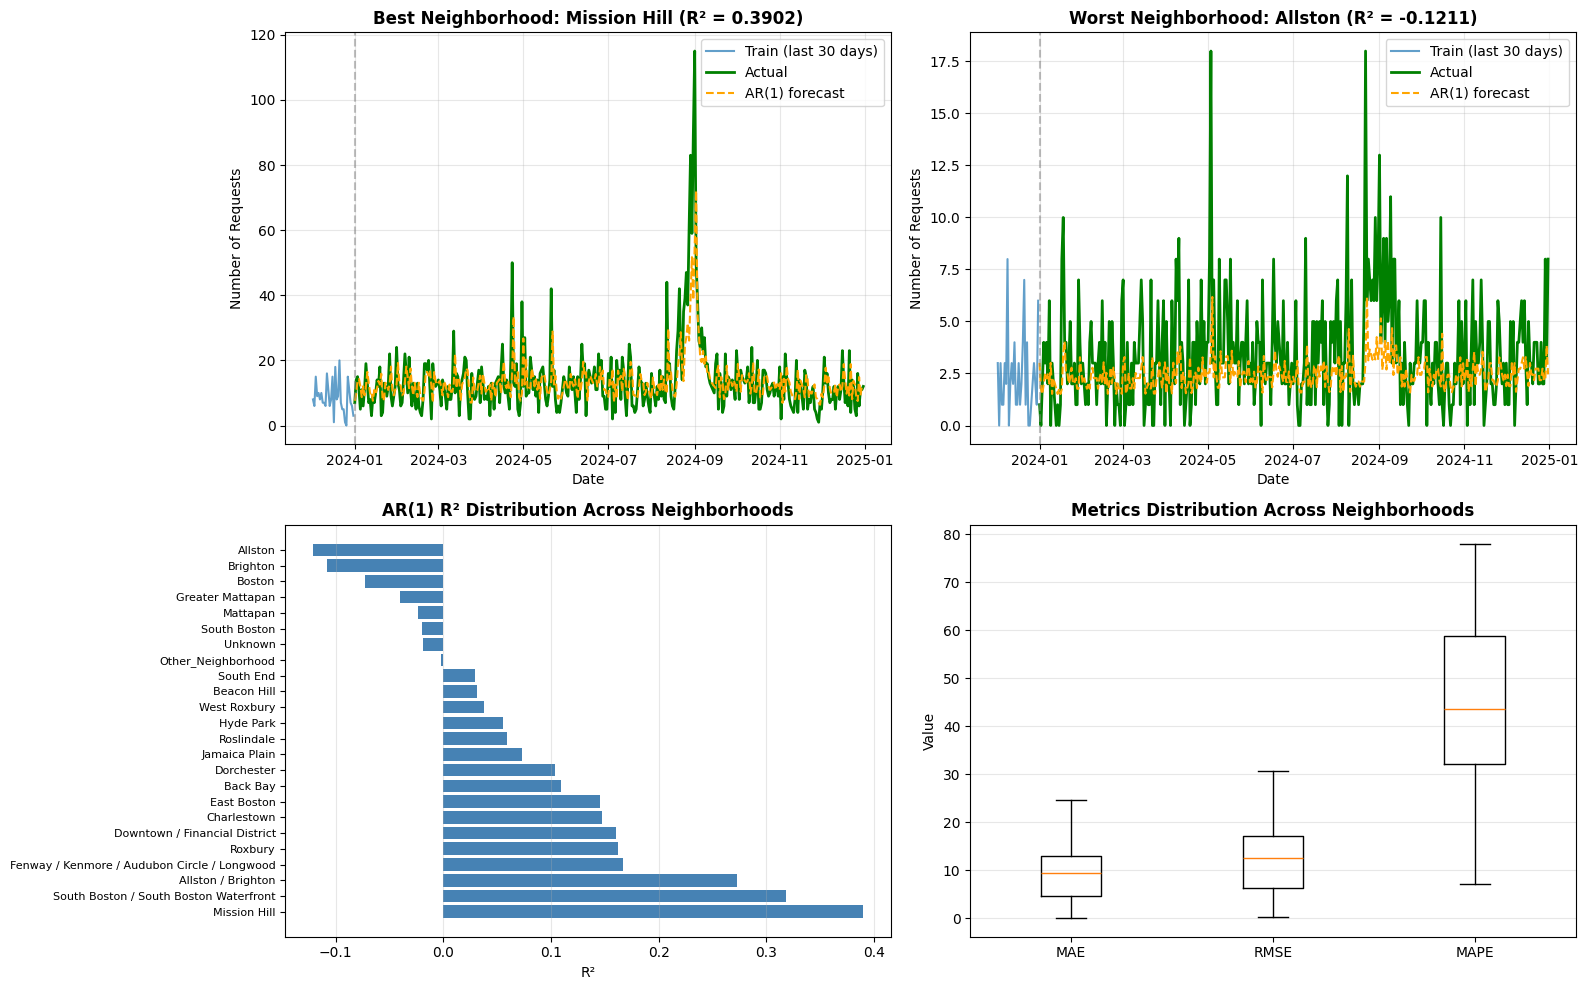

In [ ]:
# visualizations for best and worst neighborhoods
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_neighborhood(ax, neighborhood, is_best=True):
    train_nb = train_dict[neighborhood]
    test_nb = test_dict[neighborhood]
    
    y_train = train_nb['count'].astype(float).values
    y_true = test_nb['count'].astype(float).values
    
    history = y_train.tolist()
    ar1_pred = []
    for actual in y_true:
        hist = np.array(history, dtype=float)
        phi, c = np.polyfit(hist[:-1], hist[1:], 1)
        y_hat = max(0.0, c + phi * hist[-1])
        ar1_pred.append(y_hat)
        history.append(float(actual))
    
    ar1_pred = np.array(ar1_pred)
    r2 = r2_score(y_true, ar1_pred)
    
    plot_train = train_nb.tail(30)
    ax.plot(plot_train['date'], plot_train['count'], label='Train (last 30 days)', linewidth=1.5, alpha=0.7)
    ax.plot(test_nb['date'], y_true, label='Actual', linewidth=2, color='green')
    ax.plot(test_nb['date'], ar1_pred, label='AR(1) forecast', linestyle='--', linewidth=1.5, color='orange')
    ax.axvline(x=test_nb['date'].min(), color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f"{'Best' if is_best else 'Worst'} Neighborhood: {neighborhood} (R² = {r2:.4f})", fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Requests')
    ax.legend()
    ax.grid(True, alpha=0.3)

# plot best and worst neighborhoods
plot_neighborhood(axes[0, 0], best_nb, is_best=True)
plot_neighborhood(axes[0, 1], worst_nb, is_best=False)

axes[1, 0].barh(range(len(per_nb_df)), per_nb_df['R2'].values, color='steelblue')
axes[1, 0].set_yticks(range(len(per_nb_df)))
axes[1, 0].set_yticklabels(per_nb_df['neighborhood'].values, fontsize=8)
axes[1, 0].set_xlabel('R²')
axes[1, 0].set_title('AR(1) R² Distribution Across Neighborhoods', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].boxplot([per_nb_df['MAE'], per_nb_df['RMSE'], per_nb_df['MAPE']], 
                    labels=['MAE', 'RMSE', 'MAPE'])
axes[1, 1].set_title('Metrics Distribution Across Neighborhoods', fontweight='bold')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()